# 0) Imports

In [1]:
# print()는 값을 화면에 출력해 주는 함수다.
# Colab 원본 첫 셀은 !pip install yfinance 이지만, 로컬 Jupyter는 이미 .venv에 패키지가 있다.
# 노트북 안에서 pip를 다시 돌리면 C: 캐시를 건드릴 수 있어 설치 셀은 건너뛴다.
print("yfinance 등은 SMA .venv에 설치됨. !pip 생략")


yfinance 등은 SMA .venv에 설치됨. !pip 생략


In [2]:
# os는 운영체제 경로·환경변수를 다루는 표준 라이브러리다.
import os
# setdefault()는 환경변수가 아직 없을 때만 값을 넣는다. 이미 있으면 덮어쓰지 않는다.
# MPLCONFIGDIR은 matplotlib가 설정·캐시를 두는 폴더다. 기본 C:\Users\... 대신 E:로 보낸다.
os.environ.setdefault("MPLCONFIGDIR", r"E:\IT_SPACES\AI\.cache\matplotlib")
# XDG_CACHE_HOME은 여러 파이썬 라이브러리가 캐시 루트로 쓰는 환경변수다.
os.environ.setdefault("XDG_CACHE_HOME", r"E:\IT_SPACES\AI\.cache")
# TEMP / TMP는 임시 파일 폴더다. 다운로드·압축 풀기가 C:로 가지 않게 한다.
os.environ.setdefault("TEMP", r"E:\IT_SPACES\AI\.cache\tmp")
os.environ.setdefault("TMP", r"E:\IT_SPACES\AI\.cache\tmp")

# numpy는 숫자 배열(ndarray) 연산을 다루는 라이브러리다. pandas·차트 계산의 기반이다.
import numpy as np
# pandas는 표(테이블) 데이터를 다루는 라이브러리다. 시계열을 DataFrame으로 다루기 위해 쓴다.
import pandas as pd

# yfinance는 Yahoo Finance에서 주가·지수·재무제표를 받아 오는 라이브러리다.
import yfinance as yf
# set_tz_cache_location()은 시간대(timezone) 캐시 폴더를 지정한다. 기본 위치가 C:라 E:로 보낸다.
yf.set_tz_cache_location(r"E:\IT_SPACES\AI\.cache\py-yfinance")
# pandas_datareader는 FRED 같은 공개 매크로 데이터베이스에서 시계열을 받아 오는 라이브러리다.
import pandas_datareader as pdr

# plotly는 인터랙티브 차트 라이브러리다. 이 레슨 본편 그림은 matplotlib를 쓴다.
# try: import가 성공하면 except를 건너뛴다. 실패해도 노트북이 멈추지 않게 한다.
try:
    # graph_objs는 캔들·선 같은 그래프 객체를 만드는 모듈이다. 관례적으로 go 라고 줄여 부른다.
    import plotly.graph_objs as go
    # express는 한 줄로 차트를 그리는 상위 API다. 관례적으로 px 라고 줄여 부른다.
    import plotly.express as px
# import가 깨져 있으면 여기로 온다. e는 에러 객체다.

except Exception as e:
    # go/px를 None으로 두면, 나중에 plotly를 쓰는 셀이 있어도 "없는 이름" 에러 대신 값이 있다.
    go = px = None
    # type(e).__name__은 예외 종류 이름(예: ImportError)만 보여 준다.
    print('plotly 생략 (matplotlib 사용):', type(e).__name__)

    
# time은 초 단위 대기 등 시간 관련 함수가 있는 표준 모듈이다.
import time
# date는 "연-월-일"만 담는 클래스다. 시분초 없이 조회 기간을 만들기 위해 쓴다.
from datetime import date

# 1) Understanding Data-Driven Decisions data pulls

In [3]:
# date.today()는 오늘 달력 날짜를 돌려 주는 함수다. 데이터 조회 끝날을 "오늘"로 두려고 쓴다.
end = date.today()
# f-문자열은 중괄호 안에 변수 값을 넣어 글을 만든다. year/month/day는 date 객체의 속성이다.
print(f'Year = {end.year}; month= {end.month}; day={end.day}')

# date(year, month, day)는 그 날짜의 date 객체를 만든다.
# end.year-70 은 올해에서 70을 뺀 해다. 장기 매크로(GDP 등)를 보기 위해 70년 전부터 받는다.
start = date(year=end.year-70, month=end.month, day=end.day)
# 시작일과 종료일을 한 줄로 확인해, 이후 DataReader/history 호출이 같은 기간을 쓰게 한다.
print(f'Period for indexes: {start} to {end} ')


Year = 2026; month= 9; day=4
Period for indexes: 1956-09-04 to 2026-09-04 


## 1.1) GDP

In [4]:
# DataReader()는 심볼·출처·시작일로 시계열을 받아 pandas DataFrame으로 돌려 주는 함수다.
# 첫 인자 "GDPPOT"는 FRED에 등록된 미국 잠재 GDP(실질, 분기, 십억 달러) 코드다.
# 둘째 "fred"는 출처가 St. Louis Fed 데이터베이스라는 뜻이다.
# start=start 는 바로 위에서 만든 70년 전 날짜부터 받겠다는 뜻이다.
gdppot = pdr.DataReader("GDPPOT", "fred", start=start)


In [5]:
# GDPPOT 는 DataFrame 안의 원래 컬럼 이름이다. 점(.)으로 그 열을 꺼낸다.
# shift(4)는 값을 4칸 아래로 민다. 분기 데이터에서 4칸 = 1년 전 같은 분기다.
# 현재값 / 1년전값 - 1 은 전년 대비 증가율(YoY, year-over-year)이다.
# 새 컬럼 이름 'gdppot_us_yoy' 에 그 비율을 저장한다.
gdppot['gdppot_us_yoy'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(4)-1
# shift(1)은 한 칸(직전 분기)만 민다. 전분기 대비 증가율(QoQ, quarter-over-quarter)이다.
gdppot['gdppot_us_qoq'] = gdppot.GDPPOT/gdppot.GDPPOT.shift(1)-1
# tail(15)는 표의 맨 아래 15행을 보여 준다. Jupyter는 셀 마지막 값을 자동으로 표시한다.
gdppot.tail(15)


,GDPPOT,gdppot_us_yoy,gdppot_us_qoq
DATE,,,
2023-01-01,22229.482194,0.025405,0.006551
2023-04-01,22377.867950,0.026085,0.006675
2023-07-01,22527.570931,0.026560,0.006690
2023-10-01,22678.156520,0.026867,0.006685
2024-01-01,22828.945411,0.026967,0.006649
2024-04-01,22979.033391,0.026864,0.006574
2024-07-01,23126.896106,0.026604,0.006435
2024-10-01,23271.541687,0.026165,0.006254
2025-01-01,23414.656420,0.025657,0.006150


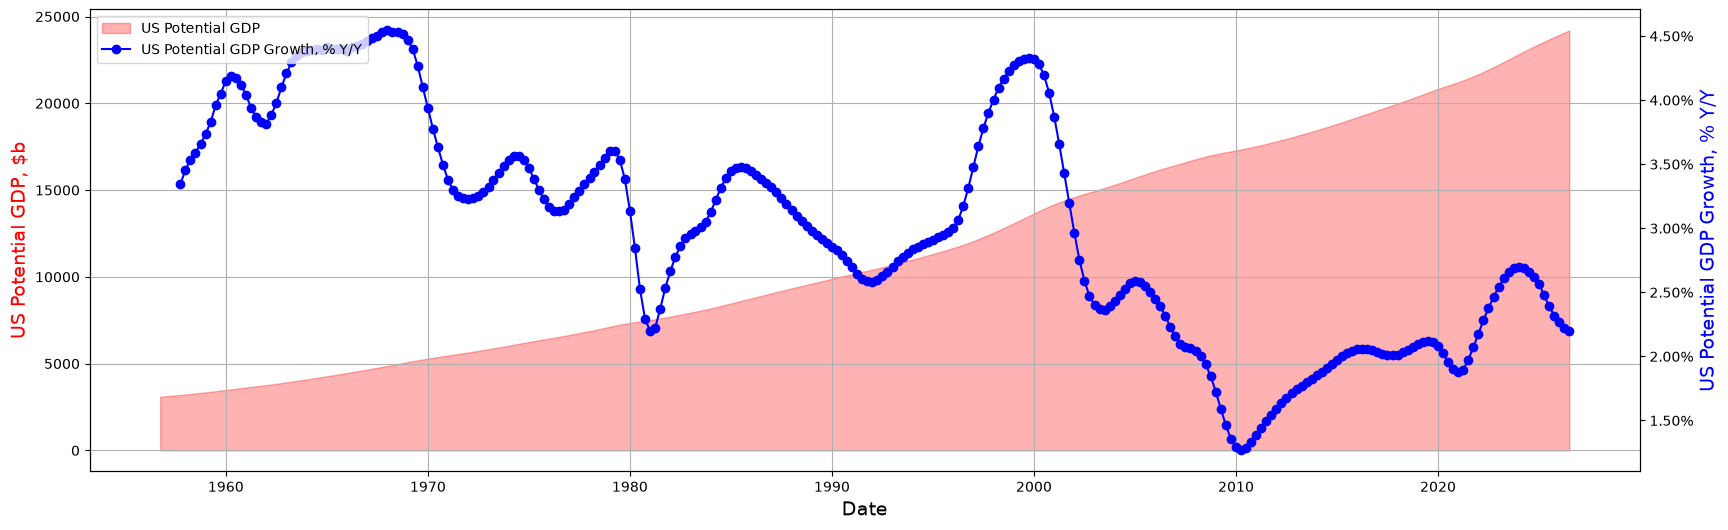

In [6]:
# matplotlib.pyplot은 그래프를 그리는 모듈이다. 관례적으로 plt 라고 줄여 부른다.
import matplotlib.pyplot as plt
# ticker 모듈은 축 눈금 숫자 표시 방식(%, 달러 등)을 바꿔 준다. mtick 으로 줄여 부른다.
import matplotlib.ticker as mtick

# subplots()는 그림(fig)과 좌표축(ax)을 한 번에 만든다.
# figsize=(20, 6)은 가로 20인치·세로 6인치라 긴 시계열이 잘 보인다.
fig, ax = plt.subplots(figsize=(20, 6))
# grid(True)는 가로·세로 격자선을 켠다. 값을 눈으로 읽기 쉽게 한다.
plt.grid(True)

# fill_between(x, y)는 x축(날짜)과 y값(GDP 수준) 사이를 색으로 채운다.
# alpha=0.3 은 투명도(0=투명, 1=불투명)다. label은 범례에 적힐 이름이다.
ax.fill_between(gdppot.index, gdppot.GDPPOT, color="red", alpha=0.3, label="US Potential GDP")

# twinx()는 같은 x축(날짜)을 공유하는 오른쪽 y축을 하나 더 만든다.
# 절대 규모(왼쪽, $b)와 성장률(오른쪽, %)을 한 그림에 겹치려고 쓴다.
ax2 = ax.twinx()
# PercentFormatter(1.0)는 0.02 같은 소수를 2% 로 눈금에 보여 준다. 1.0은 "1이 100%"라는 뜻이다.
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# plot()은 선 그래프다. marker="o" 는 각 분기 점에 동그라미를 찍는다.
ax2.plot(gdppot.gdppot_us_yoy, color="blue", marker="o", label="US Potential GDP Growth, % Y/Y")

# set_xlabel / set_ylabel 은 축 제목 글자다. fontsize는 글자 크기다.
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("US Potential GDP, $b", color="red", fontsize=14)
ax2.set_ylabel("US Potential GDP Growth, % Y/Y", color="blue", fontsize=14)

# get_legend_handles_labels()는 그 축에 그린 선(핸들)과 이름(라벨)을 꺼낸다.
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# 두 축의 범례를 합쳐 왼쪽 위(upper left)에 한 번에 보여 준다.
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# show()는 지금까지 그린 그림을 화면에 띄운다.
plt.show()


In [7]:
cpifesl = pdr.DataReader("CPILFESL", "fred", start=start)


## 1.2) Inflation - CPI Core

In [8]:
# DataReader()로 FRED에서 핵심 CPI를 받는다.
# "CPILFESL"은 식료품·에너지를 뺀 미국 핵심 소비자물가지수(월별) 코드다.
# 식료·에너지처럼 들쭉날쭉한 항목을 빼서 "물가 추세"를 보려고 이 시리즈를 쓴다.
cpilfesl = pdr.DataReader("CPILFESL", "fred", start=start)


In [9]:
# head()는 표의 맨 위 몇 행(기본 5행)을 보여 준다.
# 날짜가 인덱스로 들어왔는지, 컬럼 이름이 CPILFESL 인지 확인하려고 쓴다.
cpilfesl.head()


,CPILFESL
DATE,
1957-01-01,28.5
1957-02-01,28.6
1957-03-01,28.7
1957-04-01,28.8
1957-05-01,28.8


In [10]:
# 월별 데이터에서 shift(12)는 12개월 전, 즉 1년 전 같은 달 값이다.
# 현재 CPI / 1년 전 CPI - 1 이 핵심 물가 전년 대비 상승률(YoY)이다.
cpilfesl['cpi_core_yoy'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(12)-1
# shift(1)은 한 달 전 값이다. 전월 대비 상승률(MoM, month-over-month)이다.
cpilfesl['cpi_core_mom'] = cpilfesl.CPILFESL/cpilfesl.CPILFESL.shift(1)-1

# tail(13)은 최근 13행(약 1년+1개월)을 보여 최근 YoY가 어떻게 바뀌는지 본다.
cpilfesl.tail(13)


,CPILFESL,cpi_core_yoy,cpi_core_mom
DATE,,,
2025-07-01,328.682,0.030545,0.003125
2025-08-01,329.700,0.031118,0.003097
2025-09-01,330.418,0.030200,0.002178
2025-10-01,NaN,NaN,NaN
2025-11-01,331.043,0.025990,NaN
2025-12-01,331.814,0.026465,0.002329
2026-01-01,332.793,0.025120,0.002950
2026-02-01,333.512,0.024725,0.002161
2026-03-01,334.165,0.026022,0.001958


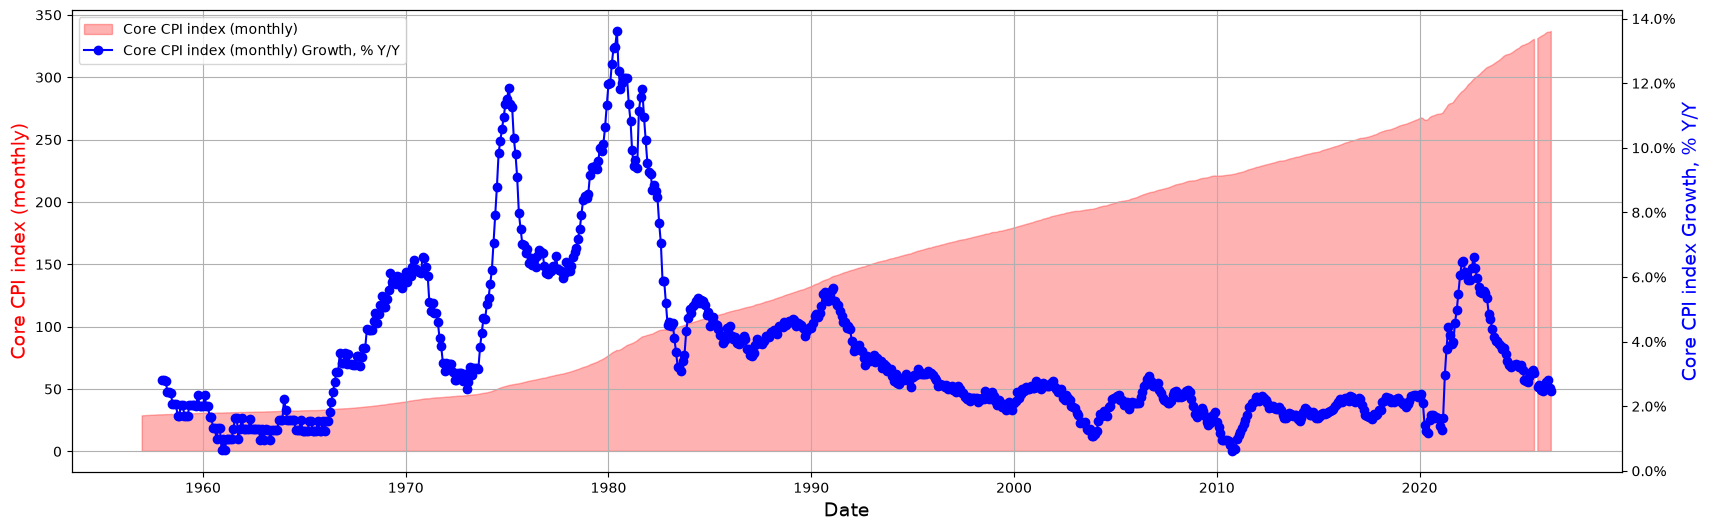

In [11]:
# GDP 때와 같은 그림 뼈대다. fig는 전체 그림, ax는 왼쪽 좌표축이다.
fig, ax = plt.subplots(figsize=(20, 6))
# 격자선을 켠다.
plt.grid(True)

# 날짜(index)와 핵심 CPI 수준 사이를 빨간 반투명 면으로 채운다.
ax.fill_between(cpilfesl.index, cpilfesl.CPILFESL, color="red", alpha=0.3, label="Core CPI index (monthly)")

# 오른쪽 y축을 하나 더 만든다. 지수 수준과 상승률 단위가 다르기 때문이다.
ax2 = ax.twinx()
# 오른쪽 눈금을 퍼센트(0.03 → 3%)로 바꾼다.
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# 핵심 CPI 전년 대비 상승률을 파란 선+점으로 그린다.
ax2.plot(cpilfesl.cpi_core_yoy, color="blue", marker="o", label="Core CPI index (monthly) Growth, % Y/Y")

# 아래 x축 제목은 날짜다.
ax.set_xlabel("Date", fontsize=14)
# 왼쪽 y축 제목은 핵심 CPI 지수 수준이다. 색을 빨간 면과 맞춘다.
ax.set_ylabel("Core CPI index (monthly)", color="red", fontsize=14)
# 오른쪽 y축 제목은 YoY 상승률이다.
ax2.set_ylabel("Core CPI index Growth, % Y/Y", color="blue", fontsize=14)

# 왼쪽 축에 그린 면의 범례 손잡이·글자를 꺼낸다.
lines, labels = ax.get_legend_handles_labels()
# 오른쪽 축에 그린 선의 범례 손잡이·글자를 꺼낸다.
lines2, labels2 = ax2.get_legend_handles_labels()
# 두 축 범례를 합쳐 왼쪽 위에 한 상자로 보여 준다.
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# 그림을 화면에 띄운다.
plt.show()


## 1.3 Interest rates

In [12]:
# "FEDFUNDS"는 미국 실효 연방기금금리(연준 기준금리에 가까운 시장 금리, 월별 %)다.
# 금리 인상·인하 사이클을  macro 그림으로 보려고 받는다.
fedfunds = pdr.DataReader("FEDFUNDS", "fred", start=start)
# tail(10)은 최근 10개월 금리를 표로 확인한다.
fedfunds.tail(10)



,FEDFUNDS
DATE,
2025-11-01,3.88
2025-12-01,3.72
2026-01-01,3.64
2026-02-01,3.64
2026-03-01,3.64
2026-04-01,3.64
2026-05-01,3.63
2026-06-01,3.63
2026-07-01,3.63


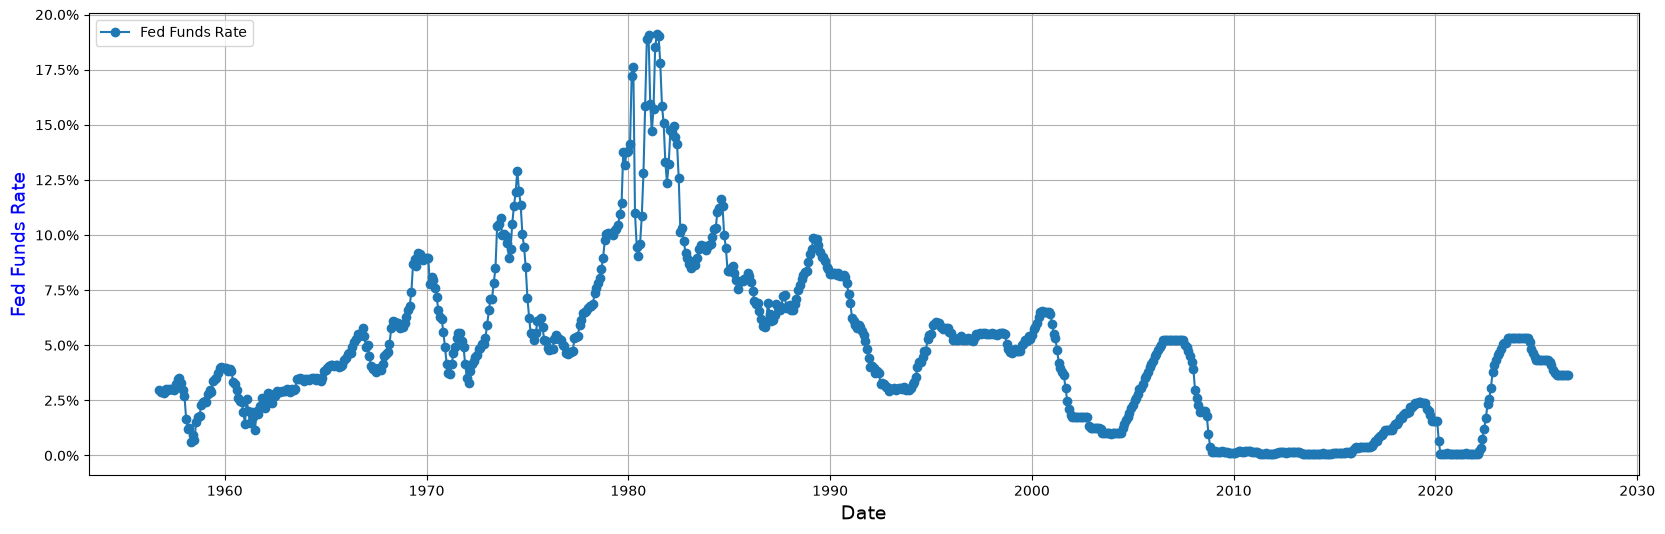

In [13]:
# 가로로 긴 시계열 그림과 좌표축을 만든다.
fig, ax = plt.subplots(figsize=(20, 6))
# 격자선을 켠다.
plt.grid(True)

# FRED의 FEDFUNDS 값은 이미 "퍼센트 숫자"(예: 5.25)다.
# PercentFormatter(1.0)는 0.05를 5%로 보여 주므로, 5.25를 0.0525로 나누어(/100) 맞춘다.
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# x는 날짜(index), y는 금리/100, marker="o" 는 월별 점이다.
ax.plot(fedfunds.index, fedfunds.FEDFUNDS/100, marker="o", label="Fed Funds Rate")

# x축 제목은 날짜다.
ax.set_xlabel("Date", fontsize=14)
# y축 제목은 연방기금금리다.
ax.set_ylabel("Fed Funds Rate", color="blue", fontsize=14)

# 이 축에 그린 선의 범례 재료를 꺼낸다.
lines, labels = ax.get_legend_handles_labels()
# 왼쪽 위에 범례를 붙인다.
ax.legend(lines, labels, loc='upper left')

# 그림을 화면에 띄운다.
plt.show()


In [14]:
# "DGS1"은 미국 1년 만기 국채 시장 수익률(일별) FRED 코드다.
# 연준 기준금리와 비교할 수 있는 단기 시장 금리다.
dgs1 = pdr.DataReader("DGS1", "fred", start=start)
# tail()은 기본 5행이다. 최근 영업일 수익률이 들어왔는지 본다.
dgs1.tail()


,DGS1
DATE,
2026-08-27,4.04
2026-08-28,4.15
2026-08-31,4.16
2026-09-01,4.18
2026-09-02,4.16


Other rates for US Treasury: https://fred.stlouisfed.org/categories/115  
* https://fred.stlouisfed.org/series/DGS2
* https://fred.stlouisfed.org/series/DGS3
* https://fred.stlouisfed.org/series/DGS5
* https://fred.stlouisfed.org/series/DGS10
...

In [15]:
# "DGS5"는 미국 5년 만기 국채 수익률이다.
# 1년물(DGS1)과 만기가 다르면 수익률 곡선(짧은 금리 vs 중간 금리)을 비교할 수 있다.
dgs5 = pdr.DataReader("DGS5", "fred", start=start)
# 최근 5영업일 5년물 금리를 표로 확인한다.
dgs5.tail()


,DGS5
DATE,
2026-08-27,4.38
2026-08-28,4.48
2026-08-31,4.49
2026-09-01,4.55
2026-09-02,4.54


## 1.4 SNP500

In [16]:
# Ticker()는 Yahoo Finance의 한 종목(또는 지수) 심볼을 감싸는 객체다.
# "^SPX"는 S&P 500 지수 심볼이다. ^ 는 지수를 뜻하는 Yahoo 관례다.
ticker_obj = yf.Ticker("^SPX")
# history()는 일별 시가·고가·저가·종가·거래량(OHLCV)을 DataFrame으로 돌려 준다.
# start/end 는 앞에서 만든 70년 기간이다.
spx_index = ticker_obj.history(start=start, end=end)
# 최근 며칠 종가가 들어왔는지 확인한다.
spx_index.tail()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-28 00:00:00-04:00,7735.169922,7771.479980,7700.910156,7711.759766,4297560000,0.0,0.0
2026-08-31 00:00:00-04:00,7697.520020,7697.520020,7665.060059,7686.140137,5386090000,0.0,0.0
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,2743361691,0.0,0.0


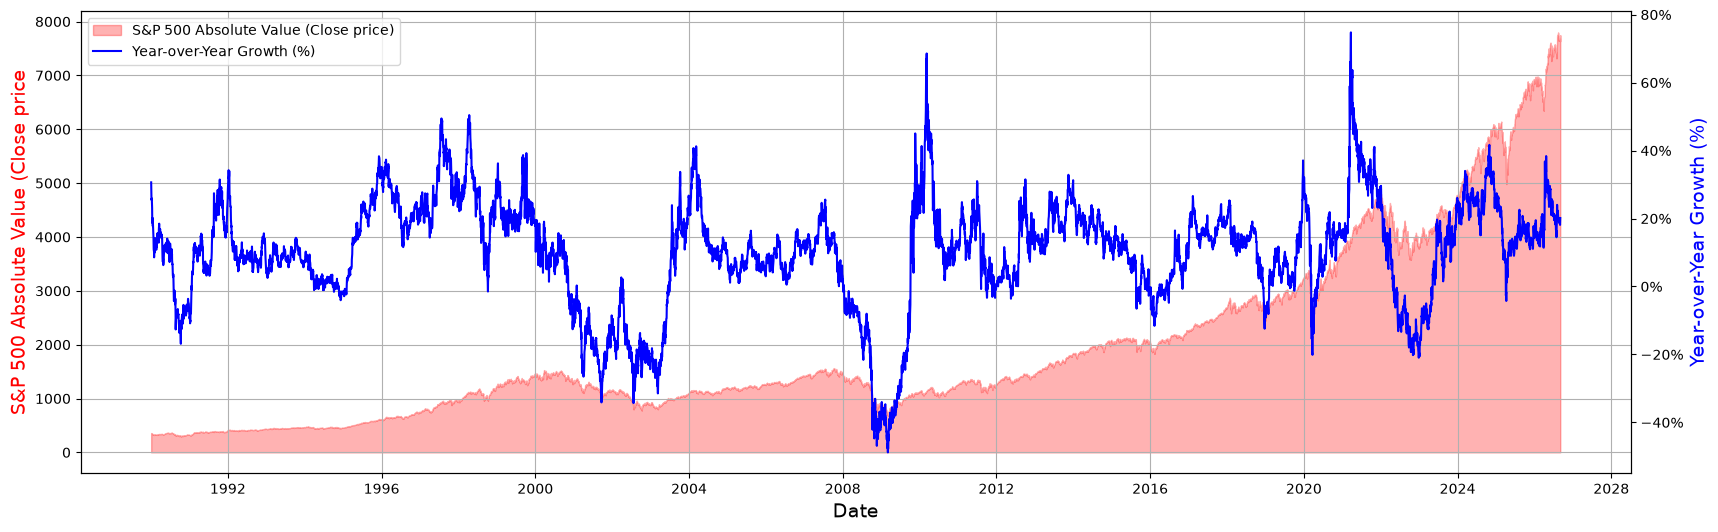

In [17]:
# 미국 주식은 1년에 약 252 거래일이다(주말·휴장 제외).
# Close.shift(252)는 약 1년 전 거래일의 종가다.
# (오늘 종가 / 1년 전 종가) - 1 이 주가지수 YoY 수익률이다.
spx_index['spx_yoy'] = (spx_index.Close / spx_index.Close.shift(252)) - 1

# 대괄호 안의 조건은 행을 고르는 필터다. 1990-01-01 이후만 남겨 그림이 너무 길어지지 않게 한다.
spx_truncated = spx_index[spx_index.index>='1990-01-01']

# 그림과 왼쪽 좌표축을 만든다.
fig, ax = plt.subplots(figsize=(20, 6))
# 격자선을 켠다.
plt.grid(True)

# 빨간 면은 S&P 500 종가 절대 수준이다.
ax.fill_between(spx_truncated.index, spx_truncated.Close, color="red", alpha=0.3, label="S&P 500 Absolute Value (Close price)")

# 오른쪽 y축을 추가한다.
ax2 = ax.twinx()
# 오른쪽 눈금을 퍼센트로 바꾼다.
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
# YoY 수익률을 파란 선으로 그린다. 이번엔 점 마커 없이 선만 쓴다.
ax2.plot(spx_truncated.spx_yoy, color="blue", label="Year-over-Year Growth (%)")

# x축 제목.
ax.set_xlabel("Date", fontsize=14)
# 왼쪽 y축 제목. 원본 문자열 끝 괄호가 비어 있는 것은 강의 노트북을 그대로 둔 것이다.
ax.set_ylabel("S&P 500 Absolute Value (Close price", color="red", fontsize=14)
# 오른쪽 y축 제목.
ax2.set_ylabel("Year-over-Year Growth (%)", color="blue", fontsize=14)

# 왼쪽 축 범례 재료.
lines, labels = ax.get_legend_handles_labels()
# 오른쪽 축 범례 재료.
lines2, labels2 = ax2.get_legend_handles_labels()
# 범례를 합쳐 왼쪽 위에 붙인다.
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

# 그림을 화면에 띄운다.
plt.show()


# 2) Data Sources for Stocks

## 2.1 OHLCV data daily - INDEXES

In [18]:
# "^GDAXI"는 독일 프랑크푸르트 DAX 주가지수 심볼이다.
ticker_obj = yf.Ticker("^GDAXI")
# history(start=start)는 시작일부터 가장 최근까지 일봉을 받는다. end를 생략하면 "오늘"까지다.
dax_daily = ticker_obj.history(start = start)


In [19]:
# tail()로 DAX 일봉 표의 최근 행(Open, High, Low, Close, Volume 등)이 들어왔는지 확인한다.
dax_daily.tail()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-27 00:00:00+02:00,26354.369141,26402.810547,26241.769531,26367.240234,49230700,0.0,0.0
2026-08-28 00:00:00+02:00,26494.609375,26618.740234,26467.359375,26569.990234,45045000,0.0,0.0
2026-08-31 00:00:00+02:00,26464.140625,26471.789062,26249.589844,26258.109375,81710600,0.0,0.0
2026-09-01 00:00:00+02:00,26150.750000,26206.130859,25916.759766,25970.109375,48552400,0.0,0.0
2026-09-02 00:00:00+02:00,25886.669922,25924.210938,25727.929688,25839.330078,47864100,0.0,0.0


In [20]:
# Close 열을 252거래일 밀어 '1년 전 종가' 컬럼을 만든다. 나중에 나눠 쓰려고 따로 저장한다.
dax_daily['adj_close_last_year'] = dax_daily['Close'].shift(252)
# 현재 종가 / 1년 전 종가 - 1 이 DAX의 YoY 수익률이다.
dax_daily['yoy_growth'] = dax_daily['Close'] / dax_daily['adj_close_last_year'] -1


In [21]:
# 변수 이름만 적으면 Jupyter가 DataFrame 전체를 표로 보여 준다.
# 컬럼 목록(Open, High, Low, Close, Dividends, Stock Splits 등)을 한눈에 보려는 확인용이다.
dax_daily


,Open,High,Low,Close,Volume,Dividends,Stock Splits,adj_close_last_year,yoy_growth
Date,,,,,,,,,
1987-12-30 00:00:00+01:00,1005.190002,1005.190002,1005.190002,1005.190002,0,0.0,0.0,NaN,NaN
1988-01-04 00:00:00+01:00,956.489990,956.489990,956.489990,956.489990,0,0.0,0.0,NaN,NaN
1988-01-05 00:00:00+01:00,996.099976,996.099976,996.099976,996.099976,0,0.0,0.0,NaN,NaN
1988-01-06 00:00:00+01:00,1006.010010,1006.010010,1006.010010,1006.010010,0,0.0,0.0,NaN,NaN
1988-01-07 00:00:00+01:00,1014.469971,1014.469971,1014.469971,1014.469971,0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-08-27 00:00:00+02:00,26354.369141,26402.810547,26241.769531,26367.240234,49230700,0.0,0.0,24039.919922,0.096811
2026-08-28 00:00:00+02:00,26494.609375,26618.740234,26467.359375,26569.990234,45045000,0.0,0.0,23902.210938,0.111612
2026-08-31 00:00:00+02:00,26464.140625,26471.789062,26249.589844,26258.109375,81710600,0.0,0.0,24037.330078,0.092389


<Axes: xlabel='Date'>

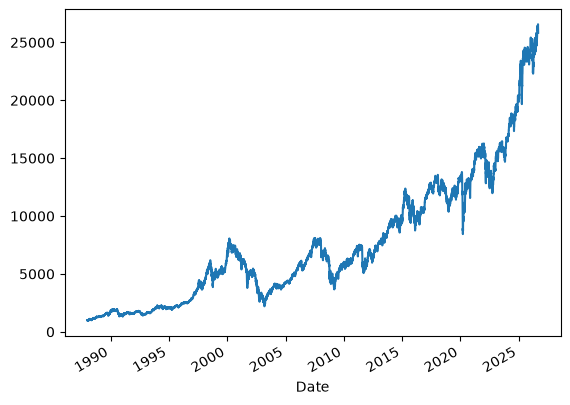

In [22]:
# pandas Series의 plot.line()은 matplotlib로 선 그래프를 바로 그린다.
# Close(종가)만 골라 DAX 장기 추세를 한 줄로 본다.
dax_daily['Close'].plot.line()


In [23]:
# "^SPX"는 S&P 500이다. 강의에서는 지연(delayed) 시세 심볼로 소개한다.
ticker_obj = yf.Ticker("^SPX")
# interval="1d"는 봉 간격이 1일(일봉)이라는 뜻이다. 분봉을 받으려면 "1m" 등을 쓴다.
snp500_daily = ticker_obj.history(start = start, interval = "1d")


In [24]:
# 최근 S&P 500(^SPX) 일봉이 들어왔는지 확인한다.
snp500_daily.tail()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-28 00:00:00-04:00,7735.169922,7771.479980,7700.910156,7711.759766,4297560000,0.0,0.0
2026-08-31 00:00:00-04:00,7697.520020,7697.520020,7665.060059,7686.140137,5386090000,0.0,0.0
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,2743361691,0.0,0.0


In [25]:
# "^GSPC"도 S&P 500이다. Yahoo에서 ^SPX와 갱신 속도가 다를 수 있어 강의에서 비교한다.
ticker_obj = yf.Ticker("^GSPC")
# 같은 시작일·일봉으로 받아 ^SPX 표와 나란히 비교할 준비를 한다.
snp500_daily_non_delayed = ticker_obj.history(start = start, interval = "1d")


In [26]:
# ^GSPC 일봉의 최근 행을 본다. ^SPX 표와 종가·시각이 같은지 눈으로 비교하면 된다.
snp500_daily_non_delayed.tail()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-08-28 00:00:00-04:00,7735.169922,7771.479980,7700.910156,7711.759766,4297560000,0.0,0.0
2026-08-31 00:00:00-04:00,7697.520020,7697.520020,7665.060059,7686.140137,5386090000,0.0,0.0
2026-09-01 00:00:00-04:00,7635.470215,7663.629883,7611.200195,7631.470215,4858180000,0.0,0.0
2026-09-02 00:00:00-04:00,7634.580078,7681.189941,7633.620117,7666.600098,4738910000,0.0,0.0
2026-09-03 00:00:00-04:00,7686.709961,7756.759766,7686.709961,7747.709961,2695072000,0.0,0.0


In [27]:
# "^DJI"는 다우존스 산업평균(미국 대형 우량 30종목 지수) 심볼이다.
ticker_obj = yf.Ticker("^DJI")
# 같은 기간·일봉으로 받아 S&P와 다른 지수도 같은 방식으로 받을 수 있음을 보여 준다.
dji_daily = ticker_obj.history(start = start, interval = "1d")


## 2.2 OHLCV data daily - ETFs

In [28]:
# "VOO"는 Vanguard S&P 500 ETF 티커다. 지수가 아니라 실제로 거래되는 펀드 가격이다.
ticker_obj = yf.Ticker("VOO")
# ETF도 주식처럼 history()로 일봉 OHLCV를 받을 수 있다.
voo_etf = ticker_obj.history(start = start, interval = "1d")


In [29]:
# VOO 최근 일봉을 본다. Dividends(배당) 열이 지수와 다르게 채워질 수 있다.
voo_etf.tail()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2026-08-28 00:00:00-04:00,709.390015,712.669983,706.260010,707.239990,8084500,0.0,0.0,0.0
2026-08-31 00:00:00-04:00,705.359985,705.940002,702.960022,704.890015,5733400,0.0,0.0,0.0
2026-09-01 00:00:00-04:00,700.450012,702.909973,698.140015,700.280029,6486900,0.0,0.0,0.0
2026-09-02 00:00:00-04:00,700.849976,704.530029,700.179993,703.409973,7742300,0.0,0.0,0.0
2026-09-03 00:00:00-04:00,NaN,NaN,NaN,NaN,8582266,0.0,0.0,0.0


In [30]:
# "EPI"는 WisdomTree 인도 기업이익 ETF다. 신흥국 ETF 예시로 배당이 Close에 어떻게 반영되는지 본다.
ticker_obj = yf.Ticker("EPI")
# 70년 기간·일봉으로 EPI 가격·배당 열을 받는다.
epi_etf_daily = ticker_obj.history(start = start, interval = "1d")


In [31]:
# head()는 상장 직후(표의 앞쪽) 며칠을 보여 준다.
epi_etf_daily.head()
# shape는 (행 개수, 열 개수) 튜플이다. 데이터가 얼마나 긴지 확인한다.
print(epi_etf_daily.shape)


(4661, 8)


In [32]:
# epi_etf_daily.Dividends>0 은 배당이 0보다 큰 날만 True인 조건이다.
# 대괄호로 그 행만 고른 뒤 tail()로 최근 배당일을 본다.
# 배당락일에는 Close가 떨어지고 Dividends 열에 금액이 찍힌다.
epi_etf_daily[epi_etf_daily.Dividends>0].tail()


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2021-12-27 00:00:00-05:00,33.577714,33.801816,33.577714,33.764465,379100,0.192,0.0,0.0
2022-03-25 00:00:00-04:00,33.563275,33.666313,33.432129,33.666313,584400,0.115,0.0,0.0
2022-06-24 00:00:00-04:00,29.420325,29.778746,29.370545,29.768789,387900,1.845,0.0,0.0
2023-06-26 00:00:00-04:00,34.020314,34.070182,33.960471,33.990395,634600,0.060,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0


In [33]:
# index는 날짜다. >= 와 <= 로 구간을 잘라 배당 전후 며칠만 본다.
# & 는 "그리고"다. 두 조건을 모두 만족하는 행만 남긴다. 괄호는 연산 순서를 명확히 한다.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [34]:
# 같은 날짜 구간을 한 번 더 출력한다.
# 강의에서 배당락 전후 Close / Dividends 숫자를 가리키며 설명하려고 셀을 나눠 둔 것이다.
epi_etf_daily[(epi_etf_daily.index >='2024-12-23') & (epi_etf_daily.index <='2024-12-28')]


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2024-12-23 00:00:00-05:00,45.609761,45.879052,45.609761,45.869080,630400,0.000,0.0,0.0
2024-12-24 00:00:00-05:00,45.719475,45.928922,45.709503,45.899002,277100,0.000,0.0,0.0
2024-12-26 00:00:00-05:00,45.840000,45.840000,45.700001,45.820000,685600,0.121,0.0,0.0
2024-12-27 00:00:00-05:00,45.570000,45.650002,45.500000,45.639999,774900,0.000,0.0,0.0


In [35]:
# download()는 티커 문자열로 가격을 한 번에 받는 함수다. Ticker.history()와 결과가 비슷하다.
# history()와 컬럼 이름·시간대(timezone)가 조금 다를 수 있어 강의에서 비교한다.
# tickers="EPI" 는 받을 종목 코드다.
epi_etf_daily2 = yf.download(tickers = "EPI",
                     # period="max" 는 Yahoo가 가진 가장 오래된 날부터 오늘까지다.
                     period = "max",
                     # interval="1d" 는 하루 봉(일봉)이다.
                     interval = "1d")


[*********************100%***********************]  1 of 1 completed


In [36]:
# download()로 받은 표에서 2024-12-23 이후만 잘라 head()로 앞부분을 본다.
# 위 셀 history() 표와 Close·Dividends가 같은지 비교하면 된다.
epi_etf_daily2[epi_etf_daily2.index>='2024-12-23'].head()


Price,Close,High,Low,Open,Volume
Ticker,EPI,EPI,EPI,EPI,EPI
Date,,,,,
2024-12-23,45.869080,45.879052,45.609761,45.609761,630400
2024-12-24,45.899002,45.928922,45.709503,45.719475,277100
2024-12-26,45.820000,45.840000,45.700001,45.840000,685600
2024-12-27,45.639999,45.650002,45.500000,45.570000,774900
2024-12-30,45.090000,45.180000,44.980000,45.180000,1442100


<Axes: title={'center': "EPI's etf stock price"}, xlabel='Date'>

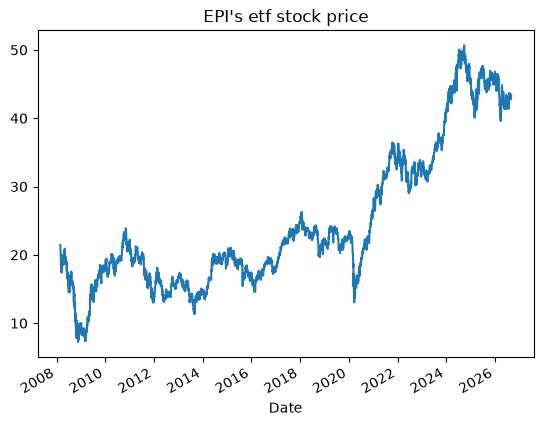

In [37]:
# plot()도 선 그래프다. title= 은 그림 위에 붙는 제목이다.
# Close만 골라 EPI ETF 가격 흐름을 본다.
epi_etf_daily['Close'].plot(title="EPI's etf stock price")


In [38]:
# Ticker('EPI')로 같은 종목 객체를 다시 만든다. 가격 표가 아니라 "이벤트"를 물을 객체다.
epi = yf.Ticker('EPI')
# get_actions()는 배당(Dividends)과 주식분할(Stock Splits) 이력을 한 표로 돌려 준다.
epi.get_actions()


,Dividends
Date,
2008-12-22 00:00:00-05:00,0.091
2009-03-23 00:00:00-04:00,0.007
2009-06-22 00:00:00-04:00,0.002
2009-09-21 00:00:00-04:00,0.045
2009-12-21 00:00:00-05:00,0.006
2010-06-28 00:00:00-04:00,0.065
2010-09-20 00:00:00-04:00,0.065
2010-12-22 00:00:00-05:00,0.013
2011-06-22 00:00:00-04:00,0.062


In [39]:
# get_dividends()는 배당만 날짜-금액 Series로 돌려 준다. 분할은 빠진다.
epi.get_dividends()


Date
2008-12-22 09:30:00-05:00    0.091
2009-03-23 09:30:00-04:00    0.007
2009-06-22 09:30:00-04:00    0.002
2009-09-21 09:30:00-04:00    0.045
2009-12-21 09:30:00-05:00    0.006
2010-06-28 09:30:00-04:00    0.065
2010-09-20 09:30:00-04:00    0.065
2010-12-22 09:30:00-05:00    0.013
2011-06-22 09:30:00-04:00    0.062
2011-09-26 09:30:00-04:00    0.098
2012-03-26 09:30:00-04:00    0.010
2012-06-25 09:30:00-04:00    0.045
2012-09-24 09:30:00-04:00    0.083
2012-12-24 09:30:00-05:00    0.024
2013-06-24 09:30:00-04:00    0.068
2013-09-23 09:30:00-04:00    0.063
2014-03-24 09:30:00-04:00    0.099
2014-06-23 09:30:00-04:00    0.059
2014-09-22 09:30:00-04:00    0.068
2015-03-23 09:30:00-04:00    0.031
2015-06-22 09:30:00-04:00    0.067
2015-09-21 09:30:00-04:00    0.116
2015-12-21 09:30:00-05:00    0.024
2016-03-21 09:30:00-04:00    0.010
2016-06-20 09:30:00-04:00    0.125
2016-09-26 09:30:00-04:00    0.070
2016-12-23 09:30:00-05:00    0.006
2017-03-27 09:30:00-04:00    0.075
2017-06-26 09:3

In [40]:
# "EICHERMOT.NS"는 인도 NSE에 상장된 Eicher Motors다. .NS 는 Yahoo의 인도 거래소 접미사다.
EICHERMOT = yf.download(tickers = "EICHERMOT.NS",
                     # 가능한 가장 긴 기간을 받는다.
                     period = "max",
                     # 일봉으로 받는다.
                     interval = "1d")


[*********************100%***********************]  1 of 1 completed


In [41]:
# 인도 종목 일봉 전체를 표로 본다. 통화·거래시간이 미국 ETF와 다를 수 있다.
EICHERMOT


Price,Close,High,Low,Open,Volume
Ticker,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS,EICHERMOT.NS
Date,,,,,
1996-01-01,1.119487,1.119487,1.119487,1.119487,22000
1996-01-02,1.122596,1.131925,1.119487,1.119487,31000
1996-01-03,1.135035,1.135035,1.135035,1.135035,11000
1996-01-04,1.135035,1.135035,1.119487,1.119487,16000
1996-01-05,1.119487,1.135035,1.100829,1.135035,6000
...,...,...,...,...,...
2026-08-28,8059.000000,8140.000000,8003.000000,8140.000000,337007
2026-08-31,7953.500000,8030.000000,7941.500000,8000.000000,742794


## 2.3 Paid data - Poligon.io (news endpoint) and Alpha Vantage

In [42]:
# 원본 Colab 셀은 Polygon.io 뉴스 API를 호출하는 예시다. 유료 API 키가 필요하다.
# 로컬 수업에서는 키를 넣지 않고, 레슨은 문서만 읽으면 되므로 호출 코드는 실행하지 않는다.
print("Polygon.io news API: 유료 키 필요. 레슨은 문서만 읽으면 됨.")


Polygon.io news API: 유료 키 필요. 레슨은 문서만 읽으면 됨.


In [43]:
# Alpha Vantage도 펀더멘털(재무) API에 키가 필요하다. 이 셀 역시 실제 HTTP 호출 없이 넘어간다.
print("Alpha Vantage: 유료/키 필요. 레슨은 문서만 읽으면 됨.")


Alpha Vantage: 유료/키 필요. 레슨은 문서만 읽으면 됨.


## 2.4 Macroeconomics

* some indicator examples: gold reserves vs. volatility

In [44]:
# 다음 셀에서 쓸 FRED 코드 TRESEGCNM052N 을 미리 알려 주는 안내 print다.
# (중국의 금 제외 외환보유액 관련 월별 시계열이다.)
print("다음 셀에서 중국 금 제외 준비금 시계열을 받음")


다음 셀에서 중국 금 제외 준비금 시계열을 받음


In [45]:
# "TRESEGCNM052N"는 중국의 금 제외 준비금(외환보유액 계열) FRED 코드다.
# 매크로 "실물 준비금" 예시로 받는다. 변수 이름 gold_reserves는 강의 원본을 따른 것이다.
gold_reserves = pdr.DataReader("TRESEGCNM052N", "fred", start=start)


<Axes: xlabel='DATE'>

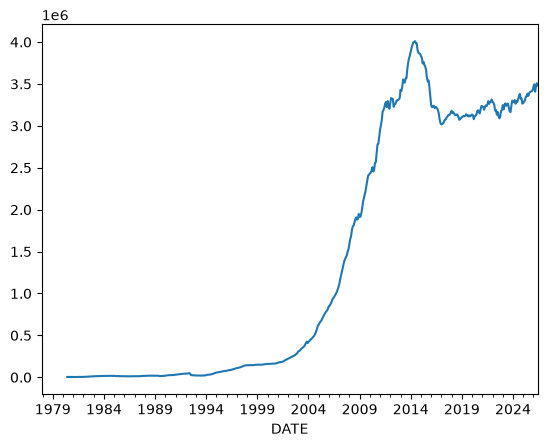

In [46]:
# 한 컬럼(TRESEGCNM052N)만 골라 plot.line()으로 장기 추세 선을 그린다.
gold_reserves.TRESEGCNM052N.plot.line()


In [47]:
# "GVZCLS"는 CBOE 금 ETF 변동성 지수다. 금 가격이 얼마나 출렁이는지(변동성)를 본다.
gold_volatility = pdr.DataReader("GVZCLS", "fred", start=start)


<Axes: xlabel='DATE'>

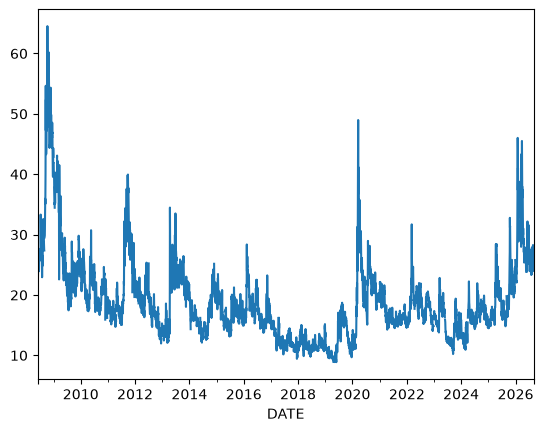

In [48]:
# 금 변동성 지수 한 열을 선으로 그린다. 위 준비금 그림과 모양이 다른지 비교하면 된다.
gold_volatility.GVZCLS.plot.line()


In [49]:
# "DCOILWTICO"는 미국 WTI(서부 텍사스) 원유 현물 가격(달러/배럴)이다.
oil_wti = pdr.DataReader("DCOILWTICO", "fred", start=start)


<Axes: xlabel='DATE'>

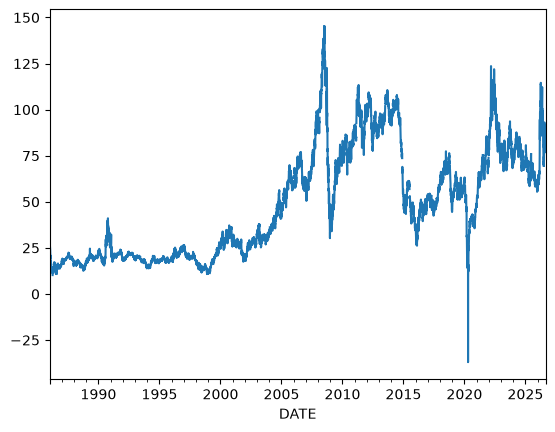

In [67]:
# WTI 가격을 선으로 그린다. 2020년 선물 만기 때 가격이 음수로 간 적이 있어 그래프가 아래로 뚫릴 수 있다.
oil_wti.DCOILWTICO.plot.line()


In [51]:
# "DCOILBRENTEU"는 유럽 브렌트유 현물 가격이다. WTI와 지역·품질이 달라 스프레드가 생긴다.
oil_brent = pdr.DataReader("DCOILBRENTEU", "fred", start=start)


<Axes: xlabel='DATE'>

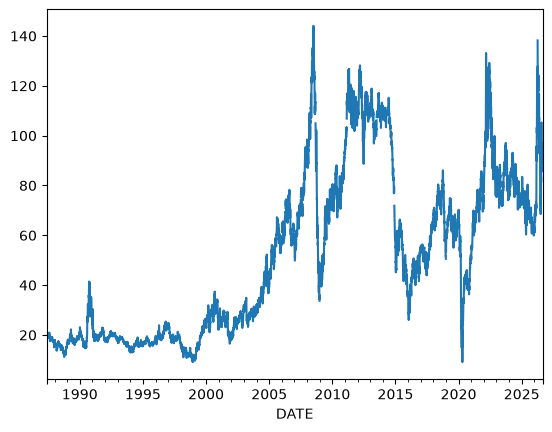

In [52]:
# 브렌트유 가격 선이다. 바로 위 WTI 그림과 비슷한 시기에 같이 움직이는지 보면 된다.
oil_brent.DCOILBRENTEU.plot.line()


In [53]:
# requests는 웹페이지를 HTTP로 받아 오는 라이브러리다. 주소창에 URL을 치는 것과 같다.
import requests
# BeautifulSoup은 받아 온 HTML 글자에서 태그(표, 링크)를 찾아 주는 파서다.
from bs4 import BeautifulSoup

# 스크레이핑할 페이지 주소다. 미국 경제지표 표가 있는 Trading Economics 페이지다.
url = "https://tradingeconomics.com/united-states/indicators"
# headers는 요청에 붙이는 부가 정보다.
# User-Agent를 브라우저처럼 쓰면, 서버가 "파이썬 봇"으로 보고 403 Forbidden을 내는 경우가 줄어든다.
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# try: 아래 요청이 성공하면 except를 건너뛴다. 네트워크 오류 때도 노트북이 멈추지 않게 한다.
try:
    # get()은 GET 요청이다. timeout=30 은 30초 안에 답이 없으면 포기한다.
    response = requests.get(url, headers=headers, timeout=30)
# except: try 안에서 어떤 에러든 나면 이 블록으로 온다. e는 에러 객체다.
except Exception as e:
    # 실패 시 다음 셀이 response.status_code 를 쓰므로, 같은 속성 이름을 가진 가짜 클래스를 만든다.
    class _R:
        # 0은 "요청 자체를 못 했다"는 표시로 쓴다. 진짜 HTTP 코드가 아니다.
        status_code = 0
        # content는 페이지 본문 바이트다. 빈 바이트로 둔다.
        content = b""
    # 가짜 응답 객체를 만들어 변수 이름을 유지한다.
    response = _R()
    # 어떤 에러였는지 화면에 남긴다.
    print("TradingEconomics 요청 실패:", e)


In [ ]:
df = pd.DataFrame()

if getattr(response, "status_code", 0) == 200:
    soup = BeautifulSoup(response.content, "html.parser")
    table_div = soup.find("div", class_="table-responsive")
    if table_div is not None:
        table = table_div.find("table")
        if table is not None:
            from io import StringIO
            df = pd.read_html(StringIO(str(table)))[0]
            print(df)
        else:
            print("table 태그를 찾지 못함")
    else:
        print("table-responsive div를 찾지 못함")

else: 
    print("Failed to retrieve data from the webpage.")

In [54]:
# 빈 DataFrame을 먼저 만든다. 페이지를 못 받아도 이후 셀이 df 이름 없음 에러로 멈추지 않게 한다.
df = pd.DataFrame()
# getattr(객체, 이름, 기본값)은 속성이 없으면 기본값을 준다. status_code가 200이면 HTTP 성공이다.
if getattr(response, "status_code", 0) == 200:
    # BeautifulSoup(..., "html.parser")는 HTML 문자열을 태그 트리로 파싱한다.
    soup = BeautifulSoup(response.content, "html.parser")
    # find("div", class_=...)는 그 CSS 클래스를 가진 첫 번째 div를 찾는다. 표가 들어 있는 상자다.
    table_div = soup.find("div", class_="table-responsive")
    # is not None 은 "찾았다"는 뜻이다. 못 찾으면 None이다.
    if table_div is not None:
        # 그 상자 안에서 <table> 태그를 찾는다.
        table = table_div.find("table")
        # 표 태그까지 있으면 pandas로 읽는다.
        if table is not None:
            # StringIO는 문자열을 파일처럼 읽게 해 주는 도구다.
            from io import StringIO
            # pandas 3는 일반 문자열을 파일 경로로 오해할 수 있어 StringIO로 감싼다.
            # read_html()은 표를 DataFrame 리스트로 읽고, [0]은 첫 번째 표다.
            df = pd.read_html(StringIO(str(table)))[0]
            # 읽힌 표를 출력해 확인한다.
            print(df)
        # table 태그가 없을 때.
        else:
            print("table 태그를 찾지 못함")
    # table-responsive div가 없을 때.
    else:
        print("table-responsive div를 찾지 못함")
# HTTP가 200이 아닐 때(403, 0, 404 등).
else:
    print("Failed to retrieve data from the webpage.")


                  Unnamed: 0     Last  Previous  Highest    Lowest  \
0                   Currency    98.98     98.99   165.00     70.70   
1               Stock Market  7748.00   7667.00  7817.00      4.40   
2            GDP Growth Rate     1.50      2.10    34.90    -28.00   
3     GDP Annual Growth Rate     2.10      2.70    13.40     -7.40   
4          Unemployment Rate     4.10      4.20    14.80      2.50   
5          Non Farm Payrolls   -23.00     20.00  4631.00 -20469.00   
6             Inflation Rate     3.40      3.50    23.70    -15.80   
7         Inflation Rate MoM     0.10     -0.40     2.00     -1.80   
8              Interest Rate     3.75      3.75    20.00      0.25   
9           Balance of Trade   -88.58    -71.18     1.95   -133.00   
10           Current Account  -227.00   -221.00     9.96   -438.00   
11    Current Account to GDP    -3.60     -4.00     0.20     -6.00   
12    Government Debt to GDP   123.00    122.00   126.00     31.80   
13         Governmen

In [55]:
# 스크레이핑으로 만든 df를 Jupyter 표로 다시 본다. 실패했으면 빈 표다.
df


,Unnamed: 0,Last,Previous,Highest,Lowest,Unnamed: 5,Unnamed: 6
0,Currency,98.98,98.99,165.00,70.70,NaN,Sep/26
1,Stock Market,7748.00,7667.00,7817.00,4.40,points,Sep/26
2,GDP Growth Rate,1.50,2.10,34.90,-28.00,percent,Jun/26
3,GDP Annual Growth Rate,2.10,2.70,13.40,-7.40,percent,Jun/26
4,Unemployment Rate,4.10,4.20,14.80,2.50,percent,Jul/26
5,Non Farm Payrolls,-23.00,20.00,4631.00,-20469.00,Thousand,Jul/26
6,Inflation Rate,3.40,3.50,23.70,-15.80,percent,Jul/26
7,Inflation Rate MoM,0.10,-0.40,2.00,-1.80,percent,Jul/26
8,Interest Rate,3.75,3.75,20.00,0.25,percent,Aug/26
9,Balance of Trade,-88.58,-71.18,1.95,-133.00,USD Billion,Jul/26


## 2.5) Financial reporting - EDGAR (in Yahoo)

In [56]:
# "NVDA"는 엔비디아의 미국 주식 티커다.
# 재무제표(손익계산서·대차대조표)를 Yahoo가 모아 둔 값을 받으려고 Ticker 객체를 만든다.
nvda =  yf.Ticker('NVDA')


In [57]:
# financials 속성은 연간 손익계산서(매출, 비용, 순이익 등) DataFrame이다.
# 행이 계정 과목, 열이 회계연도인 형태로 온다.
nvda.financials


,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,-2.841300e+08,NaN
Tax Rate For Calcs,1.511700e-01,1.326490e-01,1.200000e-01,2.100000e-01,NaN
Normalized EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,7.339000e+09,NaN
Total Unusual Items,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Total Unusual Items Excluding Goodwill,NaN,0.000000e+00,0.000000e+00,-1.353000e+09,0.0
Net Income From Continuing Operation Net Minority Interest,1.200670e+11,7.288000e+10,2.976000e+10,4.368000e+09,NaN
Reconciled Depreciation,2.843000e+09,1.864000e+09,1.508000e+09,1.543000e+09,NaN
Reconciled Cost Of Revenue,6.247500e+10,3.263900e+10,1.662100e+10,1.161800e+10,NaN
EBITDA,1.445520e+11,8.613700e+10,3.558300e+10,5.986000e+09,NaN
EBIT,1.417090e+11,8.427300e+10,3.407500e+10,4.443000e+09,NaN


In [58]:
# balance_sheet 속성은 대차대조표(자산·부채·자본) DataFrame이다.
nvda.balance_sheet


,2026-01-31,2025-01-31,2024-01-31,2023-01-31,2022-01-31
Ordinary Shares Number,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Share Issued,2.430400e+10,2.447700e+10,2.464000e+10,2.466137e+10,NaN
Net Debt,NaN,NaN,2.429000e+09,7.564000e+09,8.956000e+09
Total Debt,1.104000e+10,9.982000e+09,1.105600e+10,1.203100e+10,NaN
Tangible Book Value,1.331550e+11,7.333200e+10,3.743600e+10,1.605300e+10,NaN
...,...,...,...,...,...
Receivables,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Accounts Receivable,3.846600e+10,2.306500e+10,9.999000e+09,3.827000e+09,NaN
Cash Cash Equivalents And Short Term Investments,6.255600e+10,4.321000e+10,2.598400e+10,1.329600e+10,NaN
Other Short Term Investments,5.195100e+10,3.462100e+10,1.870400e+10,9.907000e+09,NaN


In [59]:
# fast_info는 시가총액, 전일 종가 같은 요약 숫자를 빠르게 담은 객체다.
# 전체 info 딕셔너리보다 가볍다.
nvda.fast_info


lazy-loading dict with keys = ['currency', 'dayHigh', 'dayLow', 'exchange', 'fiftyDayAverage', 'lastPrice', 'lastVolume', 'marketCap', 'open', 'previousClose', 'quoteType', 'regularMarketPreviousClose', 'shares', 'tenDayAverageVolume', 'threeMonthAverageVolume', 'timezone', 'twoHundredDayAverage', 'yearChange', 'yearHigh', 'yearLow']

In [60]:
# 대괄호 ['marketCap']은 시가총액(달러) 값을 꺼낸다.
# /1e9 는 10억으로 나누는 것이다. 1e9 = 1,000,000,000. 결과를 "십억 달러" 단위로 읽기 쉽게 한다.
nvda.fast_info['marketCap']/1e9


5516.38215

In [61]:
# yfinance가 제공하는 필드 설명은 강의가 가리키는 노트에 있다. 이 셀은 코드를 실행하지 않고 링크만 안내한다.
print("yfinance 참고: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html")


yfinance 참고: https://zoo.cs.yale.edu/classes/cs458/lectures/yfinance.html


## 2.6 Web Scraping - company info for clustering

In [62]:
# requests로 웹페이지를 다시 가져온다. 위 셀에서 이미 import했어도 이 셀만 다시 실행해도 되게 한 줄 더 둔다.
import requests
# HTML에서 링크 태그를 찾기 위해 BeautifulSoup을 다시 불러온다.
from bs4 import BeautifulSoup

# 기업 시가총액 랭킹 페이지 주소다.
url = "https://companiesmarketcap.com/"
# User-Agent를 브라우저처럼 넣어 봇 차단을 줄인다.
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3"
}

# 랭킹 HTML을 받는 구간이다. 실패해도 노트북이 멈추지 않게 try로 감싼다.
try:
    # 30초 안에 페이지 HTML을 가져온다.
    response = requests.get(url, headers=headers, timeout=30)
# 연결 실패·타임아웃이면 여기로 온다.
except Exception as e:
    print("companiesmarketcap 요청 실패:", e)
    # 아래 if가 False가 되도록 응답을 비운다.
    response = None

# 페이지를 실제로 받았고 HTTP 200일 때만 CSV 링크를 찾는다.
if response is not None and response.status_code == 200:
    # HTML을 태그 트리로 파싱한다.
    soup = BeautifulSoup(response.content, "html.parser")
    # <a rel="nofollow" href="?download=csv"> 형태의 다운로드 링크를 찾는다.
    download_link = soup.find("a", {"rel": "nofollow", "href": "?download=csv"})
    # 링크 태그를 찾았을 때만 다운로드 URL을 만든다. if download_link는 "None이 아니면"과 같다.
    if download_link:
        # href는 "?download=csv" 같은 상대주소라, 사이트 주소와 이어 전체 URL을 만든다.
        download_url = 'https://companiesmarketcap.com/'+download_link["href"]
        # CSV 파일 자체를 GET으로 받는다. 파일이 커서 timeout을 60초로 둔다.
        download_response = requests.get(download_url, headers=headers, timeout=60)
        # CSV 다운로드도 200이어야 파일로 저장한다.
        if download_response.status_code == 200:
            # "wb"는 바이너리 쓰기 모드다. 글자 변환 없이 받은 바이트를 그대로 저장한다.
            # Colab 원본은 /content/global_stocks.csv 다. 로컬은 노트북 폴더 상대 경로다.
            with open("global_stocks.csv", "wb") as f:
                # 받아 온 CSV 바이트를 파일에 쓴다.
                f.write(download_response.content)
            print("CSV file downloaded successfully.")
        # CSV URL은 찾았지만 파일 받기가 실패한 경우.
        else:
            print("Failed to download the CSV file.")
    # 페이지는 열렸지만 다운로드 링크를 못 찾은 경우.
    else:
        print("Download link not found on the webpage.")
# 랭킹 페이지 자체에 도달하지 못한 경우.
else:
    print("Failed to retrieve data from the webpage.")


CSV file downloaded successfully.


In [63]:
# Path는 파일 경로를 다루는 클래스다. 문자열이 아니라 Path 객체로 존재 여부를 검사한다.
from pathlib import Path
# 바로 위 셀이 저장한 CSV가 노트북 폴더에 있는지 본다.
_csv = Path("global_stocks.csv")
# exists()가 True면 파일이 있는 것이므로 읽는다.
if _csv.exists():
    # read_csv()는 CSV를 DataFrame으로 읽는다. 시가총액·국가·업종 컬럼이 들어 있다.
    global_stocks = pd.read_csv(_csv)
# 파일이 없으면 다운로드가 실패한 것이다.
else:
    print("global_stocks.csv 없음 — 위 셀 다운로드 실패. 이후 셀은 빈 표로 통과.")
    # marketcap 열만 있는 빈 표를 만들어 다음 셀이 이름 없음으로 죽지 않게 한다.
    global_stocks = pd.DataFrame(columns=["marketcap"])


In [64]:
# columns에 "marketcap"이 있고 행이 1개 이상일 때만 계산한다. 빈 표면 이 칸을 건너뛴다.
if "marketcap" in global_stocks.columns and len(global_stocks):
    # marketcap은 달러 단위 시가총액이다. /1e9 로 십억 달러 컬럼을 새로 만든다.
    global_stocks['marketcap_b_usd'] = global_stocks.marketcap/1e9


In [65]:
# head(10)은 시가총액 큰 기업부터 상위 10행을 보여 준다. (사이트가 이미 큰 순으로 정렬해 둔다.)
global_stocks.head(10)


,Rank,Name,Symbol,marketcap,price (USD),country,marketcap_b_usd
0,1,NVIDIA,NVDA,5516382175232,228.45000,United States,5516.382175
1,2,Apple,AAPL,4789955985408,328.21000,United States,4789.955985
2,3,Alphabet (Google),GOOG,4146926190592,339.08000,United States,4146.926191
3,4,Microsoft,MSFT,3787919458304,510.12000,United States,3787.919458
4,5,Amazon,AMZN,2792576516096,258.90000,United States,2792.576516
5,6,TSMC,TSM,2162811600896,417.01000,Taiwan,2162.811601
6,7,SpaceX,SPCX,1973839855616,149.74000,United States,1973.839856
7,8,Broadcom,AVGO,1699217408000,357.16000,United States,1699.217408
8,9,Saudi Aramco,2222.SR,1672458902383,6.91363,Saudi Arabia,1672.458902
9,10,Meta Platforms (Facebook),META,1555711000576,610.68000,United States,1555.711001


In [66]:
# info()는 각 컬럼의 자료형(int, float, object)과 결측(비어 있는 값) 개수를 요약해 보여 준다.
# 나중에 클러스터링할 때 어떤 열이 숫자인지 확인하려고 쓴다.
global_stocks.info()


<class 'pandas.DataFrame'>
RangeIndex: 11248 entries, 0 to 11247
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rank             11248 non-null  int64  
 1   Name             11248 non-null  str    
 2   Symbol           11247 non-null  str    
 3   marketcap        11248 non-null  int64  
 4   price (USD)      11248 non-null  float64
 5   country          11248 non-null  str    
 6   marketcap_b_usd  11248 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 615.3 KB
